## <span style="color:grey; font-weight:bold;">Import Tools and Def Functions</span>

In [33]:
import Def_Function
import pandas as pd
import os
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
import sys

sys.path.append('/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis')

In [34]:
importlib.reload(Def_Function)

from Def_Function import ReadandMergeAllChunk, DataFrameStandardScaler, ColumnsHist
from Def_Function import ColumnsNaNSorted, CorrHeatMap, ScatterPlot, TestTrainSplit
from Def_Function import RandomForestFeature, PCAFeature, SMOTEReSample

In [35]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [36]:
data_path = '/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Data'
os.chdir(data_path)

## <span style="color:grey; font-weight:bold;">Read & Merge Chunk</span>

In [37]:
train_df = ReadandMergeAllChunk(5)

3.Final Chunk 1.csv is Loaded
3.Final Chunk 2.csv is Loaded
3.Final Chunk 3.csv is Loaded
3.Final Chunk 4.csv is Loaded
3.Final Chunk 5.csv is Loaded
All Chunk is Read and Merged



In [21]:
train_df.head(5)

,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,0.78,1.39,2.50,0.67,5.71,2.30,0.97,1.19,1.67,...,1207693,0,3397,265,0,719842,3,36054,78,37710
1,1.00,0.56,1.79,1.88,1.62,14.19,3.84,0.97,1.80,1.87,...,47429,0,2627,187,1,1193530,2,85017,54,45167
2,0.00,0.00,4.01,2.74,1.47,11.97,3.54,0.64,1.80,2.31,...,263299,4,351,265,2,1858253,14,75814,78,64578
3,1.00,0.56,6.90,1.56,1.03,5.75,1.12,0.64,1.19,1.13,...,282304,8,1675,265,2,438551,2,94484,0,56025
4,0.00,0.00,3.33,1.34,1.03,10.83,2.71,1.56,2.84,4.91,...,75910,9,3397,265,2,1811968,2,40660,81,49152


In [22]:
train_df.iloc[:, 1:13].describe()

,1,2,3,4,5,6,7,8,9,10,11,13
count,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00
mean,0.53,2.49,1.71,1.50,10.56,3.60,1.21,2.41,3.77,0.40,0.67,1.48
std,0.34,1.62,0.61,0.65,5.00,1.65,0.83,1.47,1.72,0.48,0.43,0.65
min,0.00,0.69,0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.56,1.39,1.34,1.04,7.40,2.71,0.64,1.19,2.63,0.00,0.59,1.03
50%,0.56,1.61,1.64,1.47,11.28,3.80,1.19,2.41,3.93,0.00,0.60,1.46
75%,0.56,3.47,2.17,1.94,13.75,4.53,1.85,3.59,4.93,1.00,1.02,1.91
max,1.36,7.66,3.11,3.06,23.65,8.02,3.23,5.22,8.21,2.00,1.70,2.96


In [23]:
train_df.shape

(17140134, 38)

In [35]:
train_df['Predicted'].value_counts() / train_df['Predicted'].shape[0]*100

Predicted
0.00   75.64
1.00   24.36
Name: count, dtype: float64

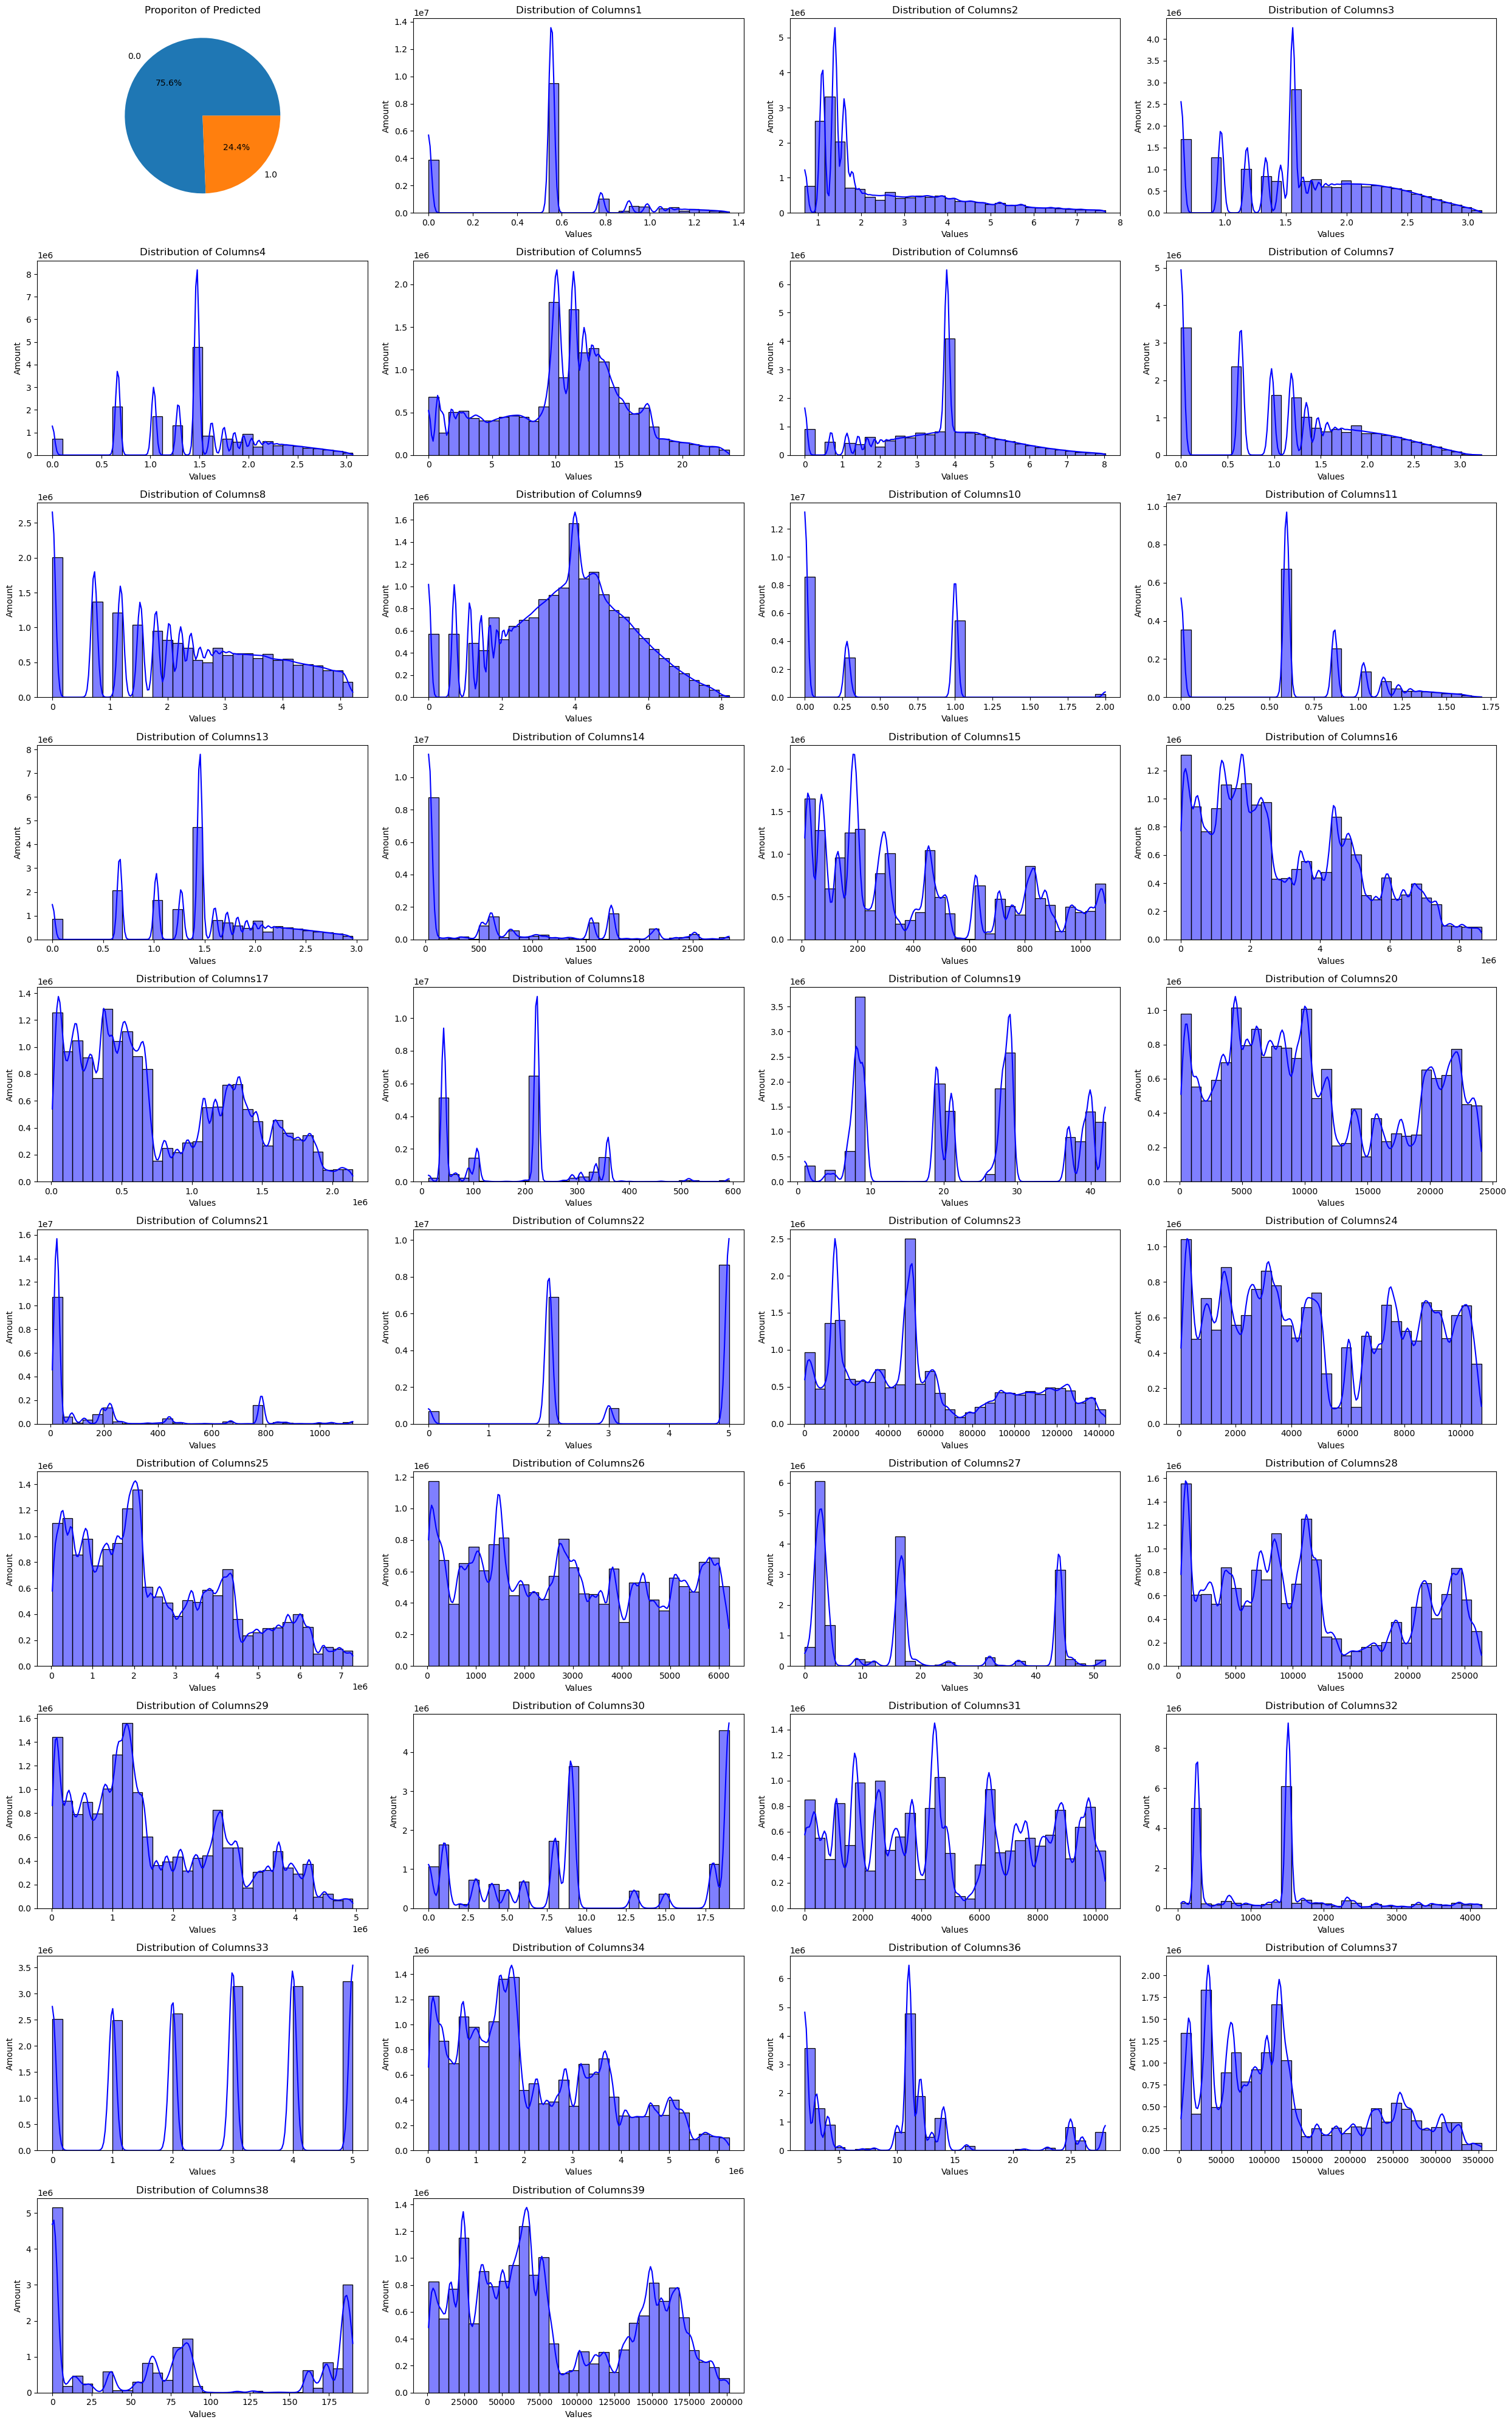

In [25]:
ColumnsHist(train_df)

<function matplotlib.pyplot.show(close=None, block=None)>

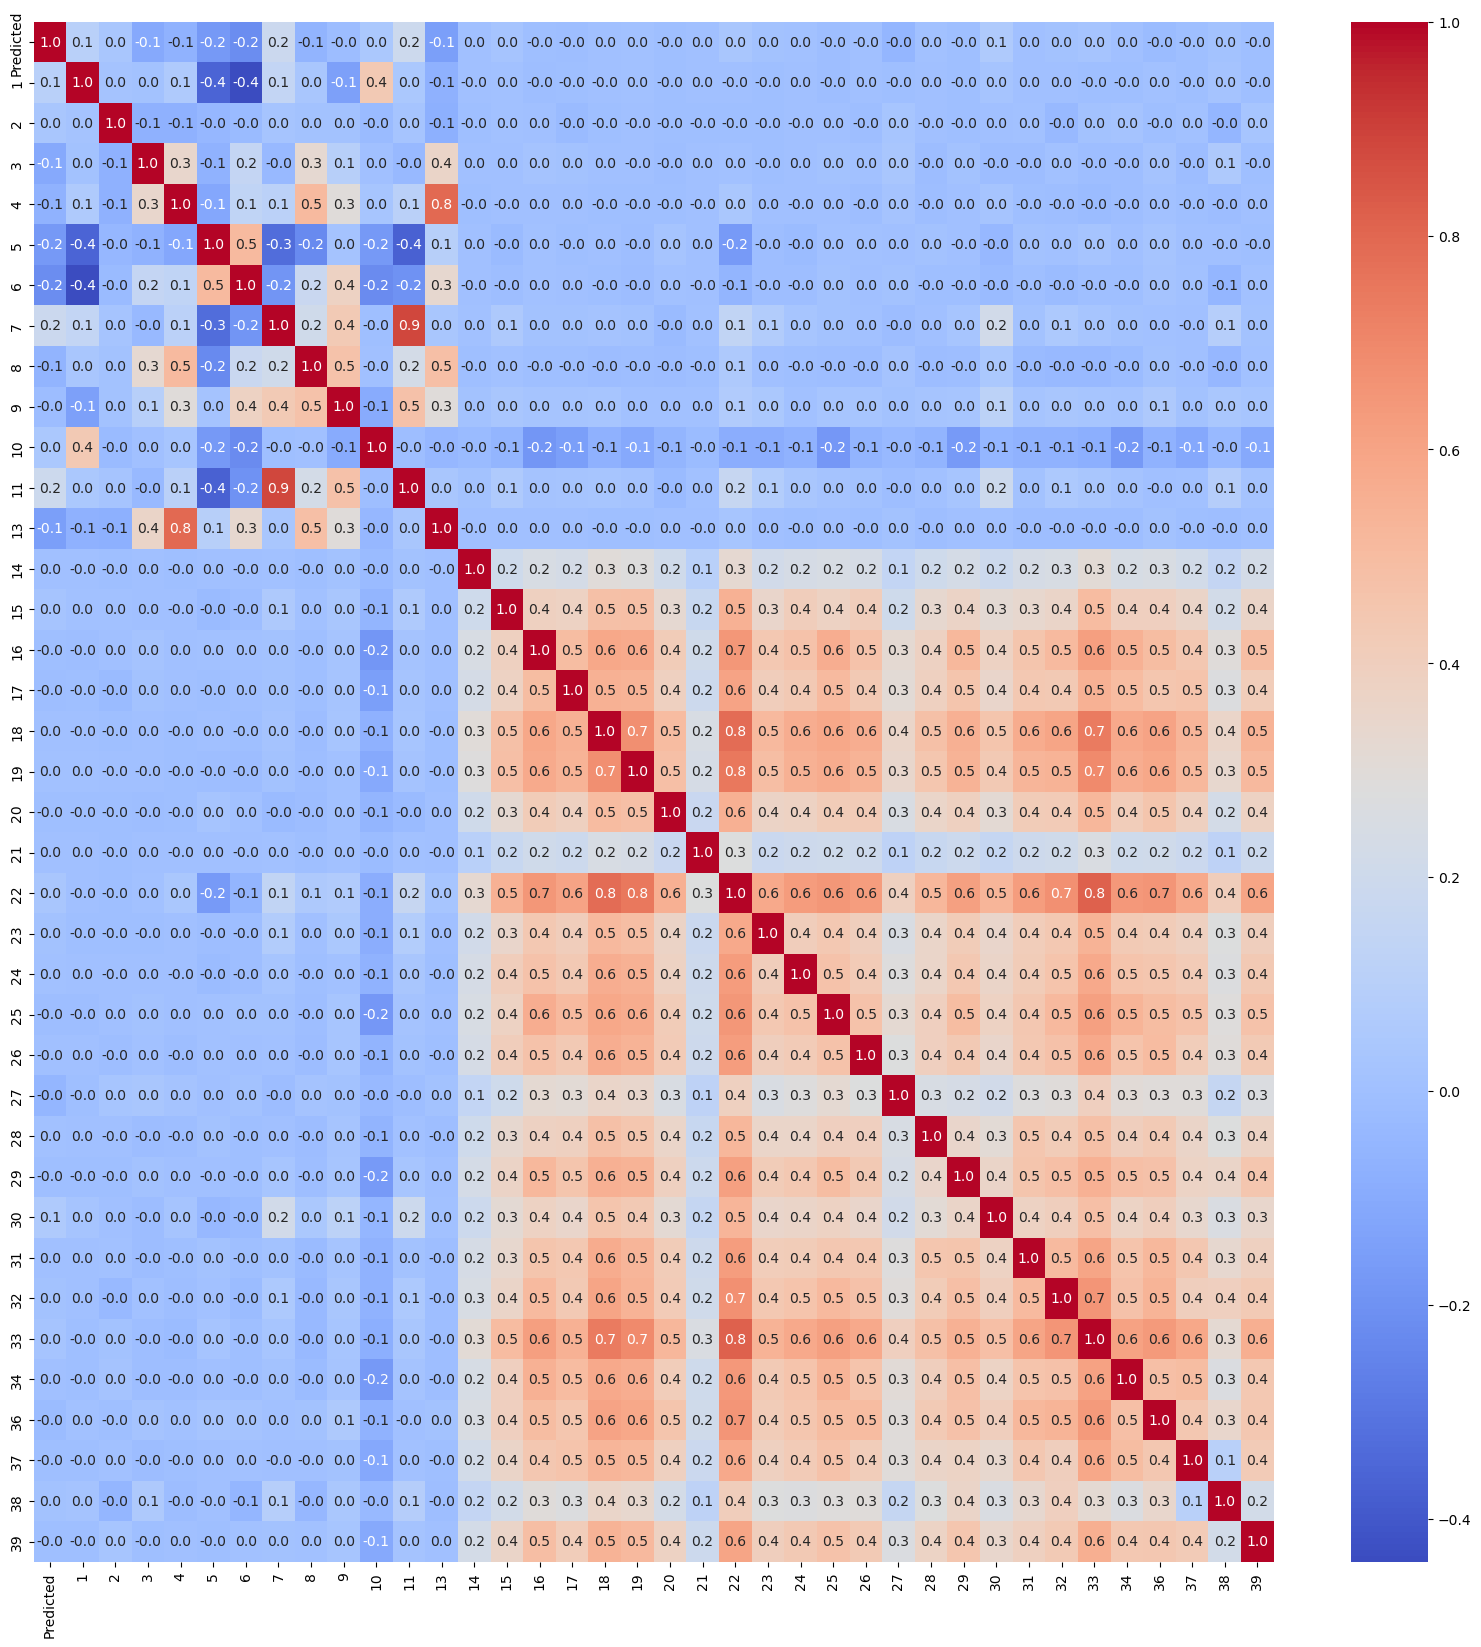

In [40]:
df_corr = train_df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.1f')
plt.show()

In [38]:
train_df = DataFrameStandardScaler(train_df)
train_df

,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,0.73,-0.68,1.31,-1.30,-0.97,-0.78,-0.30,-0.84,-1.22,...,-0.39,-1.53,-0.51,-1.06,-1.58,-0.95,-0.99,-0.96,-0.04,-0.82
1,1.00,0.08,-0.43,0.28,0.18,0.72,0.14,-0.30,-0.42,-1.11,...,-1.33,-1.53,-0.76,-1.14,-0.99,-0.64,-1.13,-0.43,-0.37,-0.68
2,0.00,-1.53,0.94,1.70,-0.05,0.28,-0.04,-0.69,-0.42,-0.85,...,-1.15,-0.94,-1.49,-1.06,-0.40,-0.21,0.55,-0.53,-0.04,-0.34
3,1.00,0.08,2.73,-0.25,-0.73,-0.96,-1.50,-0.69,-0.84,-1.54,...,-1.14,-0.35,-1.06,-1.06,-0.40,-1.13,-1.13,-0.32,-1.11,-0.49
4,0.00,-1.53,0.52,-0.61,-0.73,0.05,-0.54,0.42,0.29,0.66,...,-1.30,-0.20,-0.51,-1.06,-0.40,-0.24,-1.13,-0.91,-0.00,-0.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17140129,0.00,0.08,-0.86,-0.25,-0.05,1.29,0.22,-0.69,-1.64,0.21,...,2.55,-0.35,0.87,0.02,0.78,1.20,2.09,2.13,1.42,-1.42
17140130,0.00,-1.53,0.45,-0.41,-0.34,0.50,0.04,0.81,-0.13,0.27,...,2.03,1.28,-1.36,2.56,0.19,0.63,0.27,-0.66,1.42,1.54
17140131,0.00,-1.53,-0.54,1.08,0.37,-0.13,-0.18,0.87,0.85,-0.13,...,-0.14,1.28,0.46,1.73,0.78,0.35,0.13,-0.66,1.42,-1.38
17140132,0.00,0.08,-0.68,-1.76,-0.05,0.19,1.74,1.45,0.19,1.08,...,0.72,1.28,1.01,0.19,0.19,1.98,0.13,1.74,1.10,-0.35


In [39]:
train_df.describe()

,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
count,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,...,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00,17140134.00
mean,0.24,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,...,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,0.43,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.00,-1.53,-1.11,-1.76,-2.33,-2.11,-2.18,-1.47,-1.64,-2.19,...,-1.35,-1.53,-1.60,-1.28,-1.58,-1.40,-1.13,-1.33,-1.11,-1.48
25%,0.00,0.08,-0.68,-0.61,-0.72,-0.63,-0.54,-0.69,-0.84,-0.66,...,-0.78,-0.79,-0.85,-1.06,-0.99,-0.80,-0.99,-0.76,-1.09,-0.82
50%,0.00,0.08,-0.54,-0.12,-0.05,0.14,0.12,-0.03,-0.00,0.09,...,-0.31,-0.20,-0.14,0.19,0.19,-0.28,0.13,-0.22,-0.10,-0.27
75%,0.00,0.08,0.61,0.76,0.68,0.64,0.56,0.77,0.80,0.68,...,0.80,1.28,0.87,0.19,0.78,0.76,0.27,0.68,1.25,1.03
max,1.00,2.41,3.20,2.30,2.41,2.62,2.68,2.43,1.91,2.58,...,2.61,1.28,1.73,2.85,1.37,2.62,2.51,2.53,1.49,2.12


In [40]:
x_train, x_test, y_train, y_test = TestTrainSplit(train_df)

In [ ]:
resample_x_train, resample_y_train = SMOTEReSample(x_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


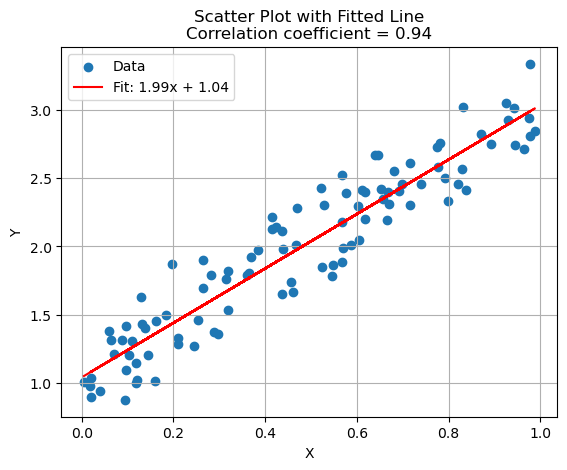

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.optimize import curve_fit

# 生成随机数
np.random.seed(0)
x = np.random.rand(100)
y = 2 * x + 1 + np.random.randn(100) * 0.2

# 计算皮尔逊相关系数
correlation_coefficient, _ = pearsonr(x, y)

# 定义线性函数
def linear_function(x, a, b):
    return a * x + b

# 使用curve_fit拟合数据
params, covariance = curve_fit(linear_function, x, y)

# 绘制散点图和拟合曲线
plt.scatter(x, y, label='Data')
plt.plot(x, linear_function(x, *params), color='red', label='Fit: {:.2f}x + {:.2f}'.format(*params))
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot with Fitted Line\nCorrelation coefficient = {:.2f}'.format(correlation_coefficient))
plt.legend()
plt.grid(True)
plt.show()
